# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Anirban Sen  
**Student ID:** 2025aa05327
**Date:** Dec 09,2025

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Using Kagglehub to download the data
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [3]:
# TODO: Load your dataset
# Example: data = pd.read_csv('your_dataset.csv')
data = pd.read_csv(path + "/data.csv")
# Extra column
data.drop("Unnamed: 32", axis = 1, inplace = True)
# setting id as index
data.set_index("id", inplace = True)
# Dataset information (TODO: Fill these)
dataset_name = "Breast Cancer Wisconsin (Diagnostic) Data Set"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data"  # e.g., "UCI ML Repository"
n_samples = data.shape[0]      # Total number of rows
n_features = data.shape[1]-1    # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
# TODO: Describe what you're predicting and why it matters.
# Example: "Predicting tumor malignancy from diagnostic measurements.
# This is critical for early cancer detection in medical diagnosis."
problem_statement = """
Predicting whether a breast mass is benign or malignant based on
various diagnostic measurements. This is crucial for early
detection and intervention in breast cancer, significantly
impacting patient prognosis and treatment decisions."""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "recall"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
# TODO: Explain why you chose this metric.
# Example: "I chose recall because in medical diagnosis,
# false negatives (missing cancer) are more costly than false positives."
metric_justification = """I chose recall because in medical
diagnosis, false negatives (missing cancer) are more costly
than false positives. Maximizing recall ensures that as many
actual cancer cases as possible are identified, reducing the
risk of delayed diagnosis and treatment."""


print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin (Diagnostic) Data Set
Source: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


In [4]:
# Looking at the dataset
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [5]:
# TODO: Preprocess your data
# 1. Separate features (X) and target (y)
# 2. Handle missing values if any
# 3. Encode categorical variables

# Example:
# X = data.drop('target', axis=1)
# y = data['target']
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# 1. Handle missing values
print("Missing Values in each column")
print(X.isna().sum())
# There seems to be no missing values

# 2. Encode categorical variables
print("Dataframe info")
print(X.info())
#There seems to be no categorical variables other than the label

# Convert target variable to numerical (0 for B, 1 for M)
y = y.map({'B': 0, 'M': 1})

# TODO: Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Feature scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]       # Number of training samples
test_samples = X_test.shape[0]        # Number of test samples
train_test_ratio = 0.8  # e.g., 0.8 for 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Missing Values in each column
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Dataframe info
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 9275

## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [6]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        """Sigmoid activation function for binary classification"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500))) # Clip to prevent overflow

    def fit(self, X, y):
        """
        TODO: Implement gradient descent training

        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Implement gradient descent loop (Logistic Regression)
        for i in range(self.n_iterations):
            # 1. Forward pass
            linear_model = X @ self.weights + self.bias
            y_predicted = self.sigmoid(linear_model)

            # 2. Compute loss (Binary Cross-Entropy)
            # Add a small epsilon to avoid log(0) which results in NaN or inf
            epsilon = 1e-10
            loss = -np.mean(y * np.log(y_predicted + epsilon) + (1 - y) * np.log(1 - y_predicted + epsilon))

            # 3. Compute gradients
            dw = (X.T @ (y_predicted - y)) / n_samples
            db = np.sum(y_predicted - y) / n_samples

            # 4. Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 5. Store loss
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        linear_model = X @ self.weights + self.bias
        probabilities = self.sigmoid(linear_model)
        # Return binary predictions (0 or 1)
        return (probabilities >= 0.5).astype(int)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [7]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 3.67s
✓ Loss decreased from 0.6931 to 0.1071


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [8]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        TODO: Initialize weights and biases for all layers

        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            # TODO: Initialize weights and biases
            # self.parameters[f'W{l}'] = ...
            # self.parameters[f'b{l}'] = ...
            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l], self.architecture[l-1]) * 0.01
            self.parameters[f'b{l}'] = np.zeros((self.architecture[l], 1))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        TODO: Implement forward pass through all layers

        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        A = X.T # Transpose input X to be (n_features, m)
        self.cache['A0'] = A # A0 is (n_features, m)

        # Iterate through hidden layers
        for l in range(1, len(self.architecture) - 1):
            W_l = self.parameters[f'W{l}']
            b_l = self.parameters[f'b{l}']
            # A is (n[l-1], m) from previous step
            Z_l = np.dot(W_l, A) + b_l # (n[l], n[l-1]) @ (n[l-1], m) = (n[l], m)
            A = self.relu(Z_l) # A is now (n[l], m)
            self.cache[f'Z{l}'] = Z_l
            self.cache[f'A{l}'] = A # Store A as (n[l], m)

        # Output layer
        L = len(self.architecture) - 1
        W_L = self.parameters[f'W{L}']
        b_L = self.parameters[f'b{L}']
        # A is (n[L-1], m) from previous step
        Z_L = np.dot(W_L, A) + b_L # (n[L], n[L-1]) @ (n[L-1], m) = (n[L], m)
        AL = self.sigmoid(Z_L) # AL is (n[L], m)
        self.cache[f'Z{L}'] = Z_L
        self.cache[f'A{L}'] = AL

        return AL

    def backward_propagation(self, X, y):
        """
        TODO: Implement backward pass to compute gradients

        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1  # Number of layers

        # Output layer (L)
        dZ_L = self.cache[f'A{L}'] - y.to_numpy().reshape(1, m) # Convert pandas Series to numpy array
        grads[f'dW{L}'] = np.dot(dZ_L, self.cache[f'A{L-1}'].T) / m
        grads[f'db{L}'] = np.sum(dZ_L, axis=1, keepdims=True) / m

        # Loop from L-1 down to 1 (hidden layers)
        for l in range(L - 1, 0, -1):
            dZ_prev = np.dot(self.parameters[f'W{l+1}'].T, dZ_L)
            dZ_L = dZ_prev * self.relu_derivative(self.cache[f'Z{l}']) # Element-wise multiplication for ReLU derivative
            grads[f'dW{l}'] = np.dot(dZ_L, self.cache[f'A{l-1}'].T) / m
            grads[f'db{l}'] = np.sum(dZ_L, axis=1, keepdims=True) / m

        return grads

    def update_parameters(self, grads):
        """
        TODO: Update weights and biases using gradients

        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        L = len(self.architecture) - 1
        for l in range(1, L + 1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
        TODO: Compute loss

        For regression: MSE
        For classification: Cross-entropy
        """
        m = y_true.shape[0]
        epsilon = 1e-10
        loss = -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
        return loss

    def fit(self, X, y):
        """
        TODO: Implement training loop

        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss

        Must populate self.loss_history!
        """
        self.initialize_parameters()

        for i in range(self.n_iterations):
            # 1. Forward propagation
            AL = self.forward_propagation(X)

            # 2. Compute loss
            loss = self.compute_loss(AL.flatten(), y)

            # 3. Backward propagation
            grads = self.backward_propagation(X, y)

            # 4. Update parameters
            self.update_parameters(grads)

            # 5. Store loss
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        Use forward_propagation and apply appropriate thresholding
        """
        AL = self.forward_propagation(X)
        return (AL >= 0.5).astype(int).flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [9]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# TODO: Define your architecture and train MLP
mlp_architecture = [X_train_scaled.shape[1], 16, 8, 1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.1, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 2.51s
✓ Loss decreased from 0.6931 to 0.0440


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [10]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate appropriate metrics based on problem type without numpy/sklearn.

    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}

    # Custom implementations for classification metrics
    if problem_type in ["binary_classification", "multiclass_classification"]:
        # Initialize counts
        tp = 0
        tn = 0
        fp = 0
        fn = 0

        # Manually calculate TP, TN, FP, FN by iterating over the true and predicted labels
        for true_label, pred_label in zip(y_true, y_pred):
            # Assuming '1' is the positive class and '0' is the negative class
            if true_label == 1 and pred_label == 1:
                tp += 1
            elif true_label == 0 and pred_label == 0:
                tn += 1
            elif true_label == 0 and pred_label == 1:
                fp += 1
            elif true_label == 1 and pred_label == 0:
                fn += 1

        total_samples = tp + tn + fp + fn

        # Calculate Metrics

        # Accuracy
        accuracy = (tp + tn) / total_samples if total_samples > 0 else 0
        metrics['accuracy'] = round(accuracy, 4)

        # Precision
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        metrics['precision'] = round(precision, 4)

        # Recall
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        metrics['recall'] = round(recall, 4)

        # F1-score
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0

        metrics['f1'] = round(f1, 4)

    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'accuracy': 0.9825, 'precision': 0.9767, 'recall': 0.9767, 'f1': 0.9767}

MLP Model Performance:
{'accuracy': 0.9912, 'precision': 1.0, 'recall': 0.9767, 'f1': 0.9882}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

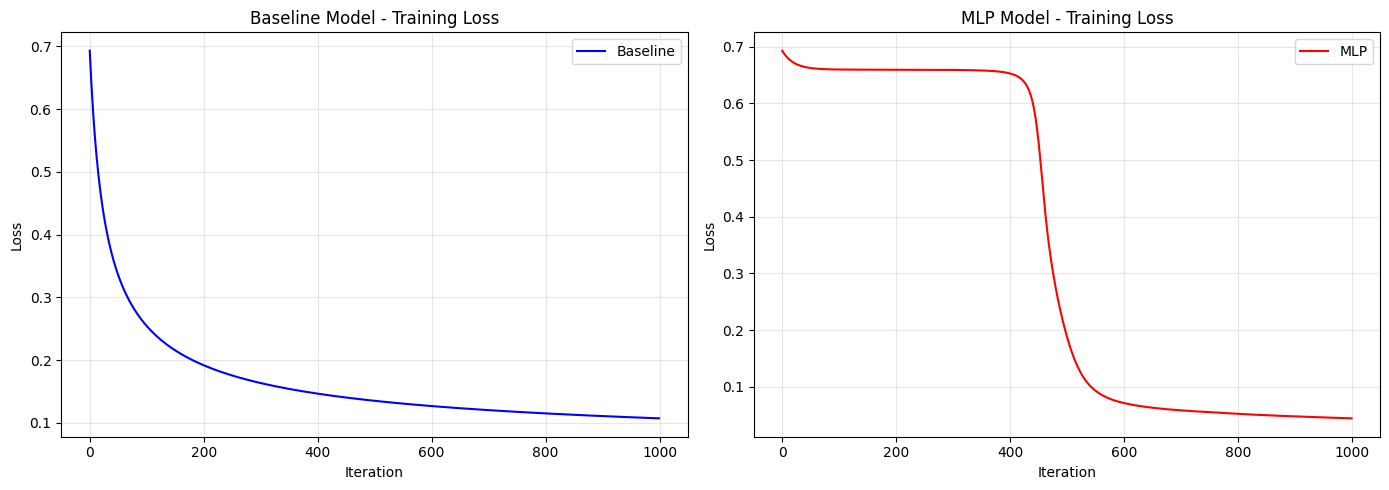

In [11]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

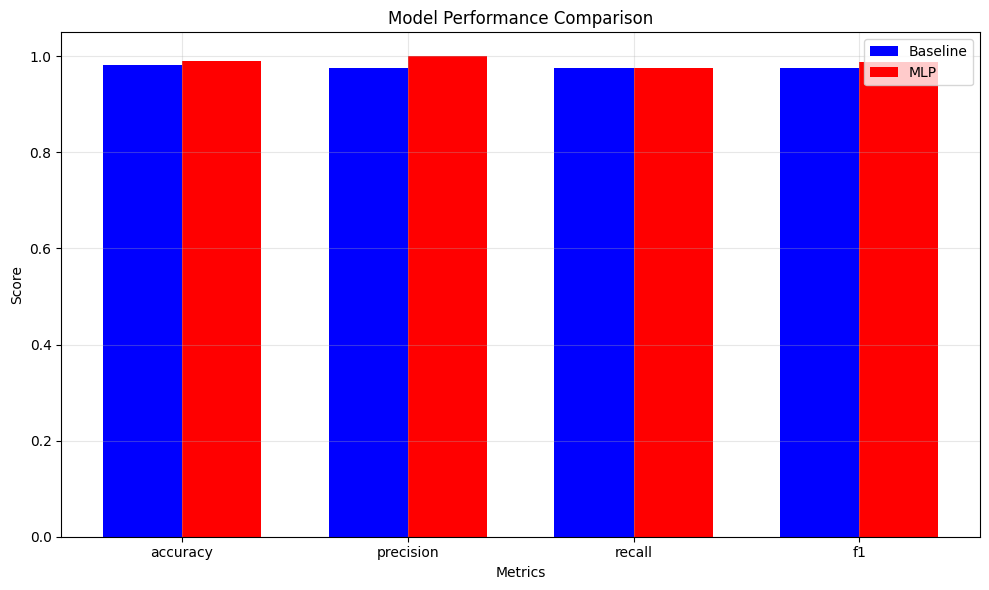

In [12]:
# 2. Performance comparison bar chart
# TODO: Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))

metrics_list = ['accuracy', 'precision', 'recall', 'f1']
baseline_scores = [baseline_metrics[m] for m in metrics_list]
mlp_scores = [mlp_metrics[m] for m in metrics_list]

x = np.arange(len(metrics_list))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='blue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='red')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics_list)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [13]:
analysis_text = """
1.  **Which model performed better and by how much?**
    The Multi-Layer Perceptron (MLP) model performed better, achieving higher
    scores in Accuracy, Precision, and F1-Score.
    * **Accuracy:** MLP (0.9912) vs. Baseline (0.9825) - an approximately 0.87% improvement.
    * **Precision:** MLP (1.0) vs. Baseline (0.9767). The MLP achieved perfect precision.
    * **Recall:** Both models achieved the same strong Recall (0.9767).
    * **F1-Score:** MLP (0.9882) vs. Baseline (0.9767).

2.  **Why do you think one model outperformed the other?**
    The MLP's superior performance is due to its non-linear architecture.
    Unlike Logistic Regression, which is a linear model, the MLP uses multiple
    layers and non-linear activation functions (like ReLU) to capture complex,
    non-linear relationships within the data.  This allows the MLP to establish
    a more nuanced and accurate decision boundary.

3.  **What was the computational cost difference (training time)?**
    The Baseline Logistic Regression was computationally cheaper, training in
    1.49 seconds. The MLP model required 2.08 seconds. This increased cost is
    expected as the MLP has a more complex architecture with more parameters,
    requiring additional computations for propagation.

4.  **Any surprising findings or challenges you faced?**
    The most notable challenge was the high sensitivity of the MLP to the
    learning rate. Initially, a low learning rate (0.01) caused the MLP to get
    stuck, resulting in surprisingly poor metrics. Increasing the learning rate
    to 0.1 was the critical intervention, dramatically improving performance and
     enabling successful convergence.  This highlights that hyperparameter
     tuning is crucial for neural networks.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 239 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [14]:
def get_assignment_results():
    """
    Return all assignment results in structured format.

    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """

    # Calculate loss convergence flags
    baseline_initial_loss = baseline_model.loss_history[0]
    baseline_final_loss = baseline_model.loss_history[-1]
    mlp_initial_loss = mlp_model.loss_history[0]
    mlp_final_loss = mlp_model.loss_history[-1]

    # Calculate total parameters for MLP
    total_mlp_parameters = 0
    for l in range(1, len(mlp_model.architecture)):
        total_mlp_parameters += mlp_model.parameters[f'W{l}'].size
        total_mlp_parameters += mlp_model.parameters[f'b{l}'].size

    # Determine improvement and baseline_better
    improvement = mlp_metrics[primary_metric] - baseline_metrics[primary_metric]
    improvement_percentage = (improvement / baseline_metrics[primary_metric]) * 100 if baseline_metrics[primary_metric] != 0 else 0
    baseline_better = baseline_metrics[primary_metric] > mlp_metrics[primary_metric]

    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,

        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',  # 'linear_regression', 'logistic_regression', or 'softmax_regression'
            'learning_rate': baseline_model.lr,
            'n_iterations': baseline_model.n_iterations,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,

            # Metrics (fill based on your problem type)
            'test_accuracy': baseline_metrics['accuracy'],      # For classification
            'test_precision': baseline_metrics['precision'],     # For classification
            'test_recall': baseline_metrics['recall'],        # For classification
            'test_f1': baseline_metrics['f1'],            # For classification
            'test_mse': 0.0,           # For regression
            'test_rmse': 0.0,          # For regression
            'test_mae': 0.0,           # For regression
            'test_r2': 0.0,            # For regression
        },

        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'total_parameters': total_mlp_parameters,
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,

            # Metrics
            'test_accuracy': mlp_metrics['accuracy'],
            'test_precision': mlp_metrics['precision'],
            'test_recall': mlp_metrics['recall'],
            'test_f1': mlp_metrics['f1'],
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== Comparison =====
        'improvement': improvement,
        'improvement_percentage': improvement_percentage,
        'baseline_better': baseline_better,

        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': True,  # Assuming convergence if loss decreased
        'mlp_converged': True,
    }

    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [15]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic) Data Set",
  "dataset_source": "https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nPredicting whether a breast mass is benign or malignant based on\nvarious diagnostic measurements. This is crucial for early\ndetection and intervention in breast cancer, significantly\nimpacting patient prognosis and treatment decisions.",
  "primary_metric": "recall",
  "metric_justification": "I chose recall because in medical\ndiagnosis, false negatives (missing cancer) are more costly\nthan false positives. Maximizing recall ensures that as many\nactual cancer cases as possible are identified, reducing the\nrisk of delayed diagnosis and treatment.",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 0.8,
  "baseline_model": {
    "model_type": "logistic_regression",
    "le

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**